In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


#01 - Basic Metrics EDA

###G1 - ManaCurve Analytics - MTG Commander Recommender

In [2]:
import json
import pandas as pd

with open("/content/gdrive/MyDrive/Capstone/AllPrintings.json", "r", encoding="utf-8") as f:
    data = json.load(f)

cards=[]

for set_code, set_data in data["data"].items():
    for card in set_data.get("cards", []):
        legalities = card.get("legalities", {})

        if legalities.get("commander") == "Legal":
            cards.append({
                "name": card.get("name"),
                "uuid": card.get("uuid"),
                "manaValue": card.get("manaValue"),
                "power": card.get("power"),
                "toughness": card.get("toughness"),
                "colors": card.get("colors"),
                "colorIdentity": card.get("colorIdentity"),
                "types": card.get("types"),
                "rarity": card.get("rarity"),
                "isLegendary": (
                "Legendary" in card.get("supertypes", [])
                if isinstance(card.get("supertypes"), list)
                else False
                ) ,
                "text": card.get("text")
            })

df = pd.DataFrame(cards)
df = df.drop_duplicates(subset=["name"])

In [3]:
df.head()

,name,uuid,manaValue,power,toughness,colors,colorIdentity,types,rarity,isLegendary,text
0,Ancestor's Chosen,5f8287b1-5bb6-5f4c-ad17-316a40d5bb0c,7.0,4,4,[W],[W],[Creature],uncommon,False,First strike (This creature deals combat damag...
2,Angel of Mercy,57aaebc1-850c-503d-9f6e-bb8d00d8bf7c,5.0,3,3,[W],[W],[Creature],uncommon,False,"Flying\nWhen this creature enters, you gain 3 ..."
4,Angelic Blessing,55bd38ca-dc73-5c06-8f80-a6ddd2f44382,3.0,None,None,[W],[W],[Sorcery],common,False,Target creature gets +3/+3 and gains flying un...
6,Angelic Chorus,3b77bb52-4181-57f5-b3cd-f3a15b95aa29,5.0,None,None,[W],[W],[Enchantment],rare,False,"Whenever a creature you control enters, you ga..."
7,Angelic Wall,fadda48c-6226-5ac5-a2b9-e9170d2017cd,2.0,0,4,[W],[W],[Creature],common,False,Defender (This creature can't attack.)\nFlying


In [4]:
import pandas as pd
from collections import Counter

#size
print("Dataset Shape (rows, columns):")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

# data types
print("\nData Types:")
print(df.dtypes)

#Clean numeric + boolean columns
df['power'] = pd.to_numeric(df['power'], errors='coerce')
df['toughness'] = pd.to_numeric(df['toughness'], errors='coerce')
df['isLegendary'] = (
    df['isLegendary']
    .fillna(False)
    .infer_objects(copy=False)
    .astype(bool)
)

#Missing values
print("\nMissing Values (count):")
print(df.isnull().sum())

print("\nMissing Values (%):")
print((df.isnull().mean() * 100).round(2))

Dataset Shape (rows, columns):
(30465, 11)

Column Names:
['name', 'uuid', 'manaValue', 'power', 'toughness', 'colors', 'colorIdentity', 'types', 'rarity', 'isLegendary', 'text']

Data Types:
name              object
uuid              object
manaValue        float64
power             object
toughness         object
colors            object
colorIdentity     object
types             object
rarity            object
isLegendary         bool
text              object
dtype: object

Missing Values (count):
name                 0
uuid                 0
manaValue            0
power            13665
toughness        13614
colors               0
colorIdentity        0
types                0
rarity               0
isLegendary          0
text               349
dtype: int64

Missing Values (%):
name              0.00
uuid              0.00
manaValue         0.00
power            44.85
toughness        44.69
colors            0.00
colorIdentity     0.00
types             0.00
rarity            0.00


In [5]:
#mana value
print("\nMana Value Summary:")
print(df['manaValue'].describe())

print("\nMana Value Skewness:")
print(df['manaValue'].skew())

# power and toughness for creatures
print("\nPower & Toughness Summary:")
print(df[['power', 'toughness']].describe())

print("\nMax Power:", df['power'].max())
print("Max Toughness:", df['toughness'].max())


Mana Value Summary:
count    30465.000000
mean         3.289414
std          1.756751
min          0.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         16.000000
Name: manaValue, dtype: float64

Mana Value Skewness:
0.6101742211400548

Power & Toughness Summary:
              power     toughness
count  16800.000000  16851.000000
mean       2.672619      2.885526
std        1.687776      1.703656
min       -1.000000     -1.000000
25%        2.000000      2.000000
50%        2.000000      3.000000
75%        3.000000      4.000000
max       20.000000     30.000000

Max Power: 20.0
Max Toughness: 30.0


In [6]:
#Rarity Dist
print("\nRarity Counts:")
print(df['rarity'].value_counts())

print("\nRarity Percentages:")
print((df['rarity'].value_counts(normalize=True) * 100).round(2))

# num of colors
df['num_colors'] = df['colors'].apply(lambda x: len(x) if isinstance(x, list) else 0)

print("\nNumber of Colors Distribution:")
print(df['num_colors'].value_counts().sort_index())

# card type freq
type_counts = Counter()

for t in df['types']:
    if isinstance(t, list):
        type_counts.update(t)

print("\nCard Type Counts:")
print(type_counts)

#legendary proportion
print("\nLegendary Distribution (%):")
print((df['isLegendary'].value_counts(normalize=True) * 100).round(2))


Rarity Counts:
rarity
common      10021
rare         9411
uncommon     9147
mythic       1877
special         9
Name: count, dtype: int64

Rarity Percentages:
rarity
common      32.89
rare        30.89
uncommon    30.02
mythic       6.16
special      0.03
Name: proportion, dtype: float64

Number of Colors Distribution:
num_colors
0     3826
1    22648
2     3278
3      646
4       15
5       52
Name: count, dtype: int64

Card Type Counts:
Counter({'Creature': 16816, 'Instant': 3507, 'Enchantment': 3486, 'Artifact': 3367, 'Sorcery': 3228, 'Land': 1066, 'Planeswalker': 293, 'Kindred': 73, 'Stickers': 48, 'Battle': 36})

Legendary Distribution (%):
isLegendary
False    88.66
True     11.34
Name: proportion, dtype: float64


#02 - Feature Engineering

In [14]:
print_df = df.copy(deep = True)
print_df.head()

,name,uuid,manaValue,power,toughness,colors,colorIdentity,types,rarity,isLegendary,text,num_colors
0,Ancestor's Chosen,5f8287b1-5bb6-5f4c-ad17-316a40d5bb0c,7.0,4.0,4.0,[W],[W],[Creature],uncommon,False,First strike (This creature deals combat damag...,1
2,Angel of Mercy,57aaebc1-850c-503d-9f6e-bb8d00d8bf7c,5.0,3.0,3.0,[W],[W],[Creature],uncommon,False,"Flying\nWhen this creature enters, you gain 3 ...",1
4,Angelic Blessing,55bd38ca-dc73-5c06-8f80-a6ddd2f44382,3.0,NaN,NaN,[W],[W],[Sorcery],common,False,Target creature gets +3/+3 and gains flying un...,1
6,Angelic Chorus,3b77bb52-4181-57f5-b3cd-f3a15b95aa29,5.0,NaN,NaN,[W],[W],[Enchantment],rare,False,"Whenever a creature you control enters, you ga...",1
7,Angelic Wall,fadda48c-6226-5ac5-a2b9-e9170d2017cd,2.0,0.0,4.0,[W],[W],[Creature],common,False,Defender (This creature can't attack.)\nFlying,1


In [15]:
# Mana bucket feature
print_df["mana_bucket"] = pd.cut(
    print_df["manaValue"],
    bins=[-1, 2, 5, 20],
    labels=["Low", "Mid", "High"]
)

print_df["mana_bucket"].value_counts()

,count
mana_bucket,
Mid,16683
Low,10573
High,3209


In [16]:
# Number of colors
print_df["num_colors"] = print_df["colors"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

print_df["num_colors"].value_counts().sort_index()

,count
num_colors,
0,3826
1,22648
2,3278
3,646
4,15
5,52


In [17]:
#Card Type Indicators
print_df["is_creature"] = print_df["types"].apply(
    lambda x: "Creature" in x if isinstance(x, list) else False
)

print_df["is_land"] = print_df["types"].apply(
    lambda x: "Land" in x if isinstance(x, list) else False
)

print_df[["is_creature", "is_land"]].value_counts()

is_creature  is_land
True         False      16815
False        False      12584
             True        1065
True         True           1
Name: count, dtype: int64

In [21]:
# Rules text length
print_df["text_length"] = print_df["text"].apply(
    lambda x: len(x) if isinstance(x, str) else 0
)

# Binary indicator
print_df["has_rules_text"] = print_df["text_length"] > 0
print_df['has_rules_text'].value_counts()

,count
has_rules_text,
True,30116
False,349


In [23]:
#Multi-Hot Encoding Colors
ALL_COLORS = ["W", "U", "B", "R", "G"]

for c in ALL_COLORS:
    print_df[f"color_{c}"] = print_df["colors"].apply(
        lambda x: c in x if isinstance(x, list) else False
    )

print_df[[f"color_{c}" for c in ALL_COLORS]].head()

,color_W,color_U,color_B,color_R,color_G
0,True,False,False,False,False
2,True,False,False,False,False
4,True,False,False,False,False
6,True,False,False,False,False
7,True,False,False,False,False


In [27]:
#Multi-Hot Encoding Card Types
MAJOR_TYPES = ["Creature", "Instant", "Sorcery", "Artifact", "Enchantment", "Land"]

for t in MAJOR_TYPES:
    print_df[f"type_{t}"] = print_df["types"].apply(
        lambda x: t in x if isinstance(x, list) else False
    )
print_df['types'].value_counts()


,count
types,
[Creature],15461
[Instant],3484
[Enchantment],3222
[Sorcery],3205
[Artifact],2218
"[Artifact, Creature]",1116
[Land],1044
[Planeswalker],292
"[Enchantment, Creature]",238


In [28]:
#Rarity Encoding
RARITY_MAP = {
    "common": 1,
    "uncommon": 2,
    "rare": 3,
    "mythic": 4
}

print_df["rarity_ord"] = print_df["rarity"].str.lower().map(RARITY_MAP)
print_df["rarity_ord"].value_counts()

,count
rarity_ord,
1.0,10021
3.0,9411
2.0,9147
4.0,1877


In [30]:
def to_numeric(val):
    try:
        return float(val)
    except:
        return np.nan

print_df["power_num"] = print_df["power"].apply(to_numeric)
print_df["toughness_num"] = print_df["toughness"].apply(to_numeric)

In [32]:
print_df[[
    "power_num",
    "toughness_num"
]].head()

,power_num,toughness_num
0,4.0,4.0
2,3.0,3.0
4,NaN,NaN
6,NaN,NaN
7,0.0,4.0


In [33]:
#Correlation Analysis
numeric_features = [
    "manaValue",
    "num_colors",
    "text_length",
    "power_num",
    "toughness_num",
    "rarity_ord"
]

corr_df = print_df[numeric_features]
corr_df.corr()

,manaValue,num_colors,text_length,power_num,toughness_num,rarity_ord
manaValue,1.000000,0.222595,0.132974,0.707481,0.679382,0.271673
num_colors,0.222595,1.000000,0.130910,0.088994,0.100735,0.157915
text_length,0.132974,0.130910,1.000000,0.137882,0.144928,0.391928
power_num,0.707481,0.088994,0.137882,1.000000,0.694207,0.276962
toughness_num,0.679382,0.100735,0.144928,0.694207,1.000000,0.299360
rarity_ord,0.271673,0.157915,0.391928,0.276962,0.299360,1.000000


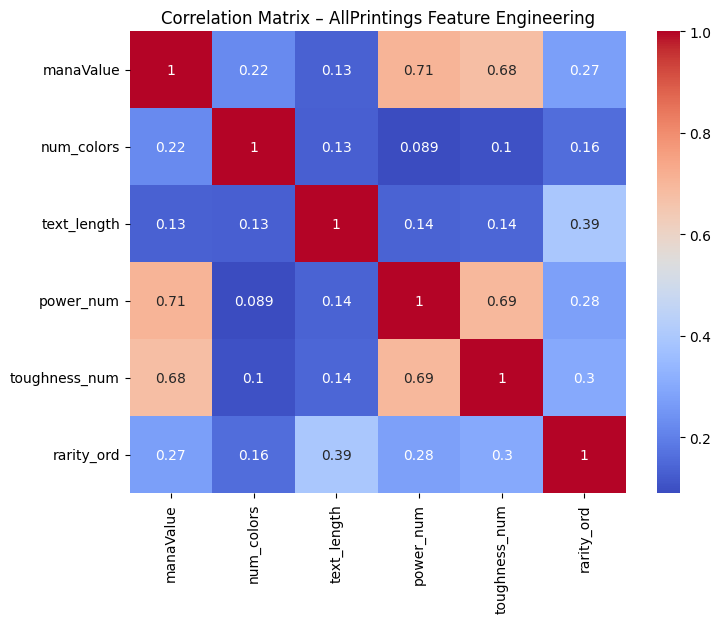

In [35]:
#Correlation Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix – AllPrintings Feature Engineering")
plt.show()

In [34]:
#Correlation of Features among Creatures only
creature_df = print_df[print_df["is_creature"]]

creature_df[numeric_features].corr()

,manaValue,num_colors,text_length,power_num,toughness_num,rarity_ord
manaValue,1.000000,0.054677,0.145490,0.715326,0.687816,0.275715
num_colors,0.054677,1.000000,0.173757,0.100705,0.109798,0.277961
text_length,0.145490,0.173757,1.000000,0.130383,0.137376,0.455934
power_num,0.715326,0.100705,0.130383,1.000000,0.690574,0.276072
toughness_num,0.687816,0.109798,0.137376,0.690574,1.000000,0.297384
rarity_ord,0.275715,0.277961,0.455934,0.276072,0.297384,1.000000


In [37]:
#Feature Matrix
feature_columns = (
    [
        "manaValue",
        "num_colors",
        "text_length",
        "is_creature",
        "is_land",
        "has_rules_text",
        "rarity_ord"
    ] +
    [f"color_{c}" for c in ALL_COLORS] +
    [f"type_{t}" for t in MAJOR_TYPES]
)

X_allprintings = print_df[feature_columns].astype(float)
X_allprintings.head()

,manaValue,num_colors,text_length,is_creature,is_land,has_rules_text,rarity_ord,color_W,color_U,color_B,color_R,color_G,type_Creature,type_Instant,type_Sorcery,type_Artifact,type_Enchantment,type_Land
0,7.0,1.0,163.0,1.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,5.0,1.0,50.0,1.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,3.0,1.0,126.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
6,5.0,1.0,77.0,0.0,0.0,1.0,3.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,2.0,1.0,45.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
